# Decision Tree

## Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('Position_Salaries.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print(X)
print(y)

            Position  Level
0   Business Analyst      1
1  Junior Consultant      2
2  Senior Consultant      3
3            Manager      4
4    Country Manager      5
5     Region Manager      6
6            Partner      7
7     Senior Partner      8
8            C-level      9
9                CEO     10
0      45000
1      50000
2      60000
3      80000
4     110000
5     150000
6     200000
7     300000
8     500000
9    1000000
Name: Salary, dtype: int64


## Encode categorical data

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = ct.fit_transform(X)

In [4]:
print(X)

  (0, 0)	1.0
  (0, 10)	1.0
  (1, 4)	1.0
  (1, 10)	2.0
  (2, 8)	1.0
  (2, 10)	3.0
  (3, 5)	1.0
  (3, 10)	4.0
  (4, 3)	1.0
  (4, 10)	5.0
  (5, 7)	1.0
  (5, 10)	6.0
  (6, 6)	1.0
  (6, 10)	7.0
  (7, 9)	1.0
  (7, 10)	8.0
  (8, 1)	1.0
  (8, 10)	9.0
  (9, 2)	1.0
  (9, 10)	10.0


## Training the Decision Tree Regression model

In [5]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X, y)

DecisionTreeRegressor(random_state=0)

In [6]:
print(regressor.predict(X))

[  45000.   50000.   60000.   80000.  110000.  150000.  200000.  300000.
  500000. 1000000.]


In [7]:
predict_data_transformed = ct.transform([['Manager',6.5]])

C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [8]:
print(predict_data_transformed)

  (0, 5)	1.0
  (0, 10)	6.5


In [9]:
regressor.predict(predict_data_transformed)

array([110000.])

In [10]:
print(len(X))
print(len())

TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

ValueError: x and y must be the same size

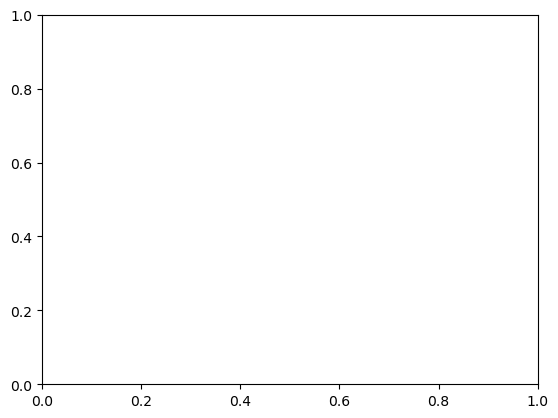

In [11]:
plt.scatter(X, y, color='blue')
plt.plot(X, regressor.predict(X), color='red')
plt.show()